In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

load /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/Full_384_strain_collection_no_seq_info.csv and /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/map_10_4_xgb.csv then do an inner join on Strain.Number and strain

In [58]:
# load and inner-join the two CSVs on Strain.Number (left) and strain (right)
path_full = "/home/rl/scripts/karl/pairwise_interaction_experiments/20260630/strain_check/Full_384_strain_collection_no_seq_info.csv"
path_map = "/home/rl/scripts/karl/pairwise_interaction_experiments/20260630/strain_check/map_10_4_xgb.csv"

df_full = pd.read_csv(path_full, dtype=str)
df_map = pd.read_csv(path_map, dtype=str)

# normalize keys
df_full['Strain.Number'] = df_full['Strain.Number'].str.strip()
df_map['strain'] = df_map['strain'].str.strip()

# inner join

df_merged = df_full.merge(df_map, left_on='Strain.Number', right_on='strain', how='inner')

print(f"full: {df_full.shape}, map: {df_map.shape}, merged: {df_merged.shape}")
df_merged.head()
display(df_merged)
df_merged.to_csv("/home/rl/scripts/karl/pairwise_interaction_experiments/20260630/strain_pool.csv", index=False)
print("Saved merged dataframe to strain_pool.csv")

full: (384, 7), map: (100, 2), merged: (100, 9)


,Well.position,Strain.Number,Well.number,Well,Schulenberg_strain_name,duplicated,*Some strain occur in more than one well,Strain_ID,strain
0,A1,1,1,A,NaN,no,NaN,1,1
1,A2,2,2,A,NaN,no,NaN,67,2
2,A6,12,6,A,NaN,no,NaN,14,12
3,A8,16,8,A,NaN,no,NaN,39,16
4,A10,18,10,A,NaN,no,NaN,51,18
...,...,...,...,...,...,...,...,...,...
95,P15,128,15,P,NaN,no,NaN,18,128
96,P17,132,17,P,NaN,no,NaN,22,132
97,P19,134,19,P,NaN,no,NaN,23,134
98,P21,136,21,P,NaN,no,NaN,24,136


Saved merged dataframe to strain_pool.csv


In [59]:
#print unique values from well positions in the merged dataframe
print("Unique well positions in merged dataframe:")
print(df_merged['Well.position'].unique())
print(len(df_merged['Well.position'].unique()))

Unique well positions in merged dataframe:
['A1' 'A2' 'A6' 'A8' 'A10' 'A11' 'A12' 'A14' 'A15' 'A21' 'C14' 'C20' 'C22'
 'C24' 'D23' 'E2' 'E4' 'E5' 'E6' 'E7' 'E8' 'E9' 'E10' 'E12' 'E13' 'E14'
 'E15' 'E16' 'E18' 'E20' 'E21' 'E22' 'E24' 'F5' 'F7' 'F13' 'F15' 'F17'
 'F19' 'F21' 'F23' 'G1' 'G2' 'G3' 'G4' 'G5' 'G6' 'G7' 'G8' 'G9' 'G10'
 'G11' 'G12' 'G13' 'G14' 'G15' 'G17' 'G18' 'G19' 'G20' 'G21' 'G22' 'G23'
 'H5' 'H7' 'H11' 'H15' 'H17' 'H19' 'H23' 'I3' 'I9' 'I11' 'J1' 'J3' 'J5'
 'J9' 'J11' 'J13' 'M9' 'M11' 'M13' 'M17' 'M19' 'M21' 'O3' 'O7' 'O9' 'O11'
 'O13' 'O15' 'O17' 'O19' 'O21' 'P11' 'P15' 'P17' 'P19' 'P21' 'P23']
100


In [68]:
pick_df = pd.read_csv("/home/rl/scripts/karl/pairwise_interaction_experiments/20260630/strain_check/picklist_Plate5(3).csv")
display(pick_df)
print("Unique well positions in picklist:")
print(pick_df['Source Well'].unique())
print(len(pick_df['Source Well'].unique()))

,Source Well,Transfer Volume (nL),Destination Well
0,G20,600.0,A2
1,J9,600.0,A2
2,F23,600.0,A3
3,M21,600.0,A3
4,G9,600.0,A4
...,...,...,...
5203,A2,75.0,P23
5204,H17,75.0,P23
5205,H19,75.0,P23
5206,O11,75.0,P23


Unique well positions in picklist:
['G20' 'J9' 'F23' 'M21' 'G9' 'O11' 'E13' 'E20' 'P17' 'O15' 'H19' 'O19'
 'E10' 'A6' 'E12' 'H5' 'H7' 'E14' 'H17' 'M11' 'O3' 'E15' 'E18' 'E22' 'O13'
 'G21' 'P23' 'I9' 'P11' 'A2' 'A21' 'G4' 'G14' 'E8' 'E21' 'C24' 'A12' 'P15'
 'M13' 'A1' 'E16' 'P19' 'A11' 'G19' 'E5' 'J1' 'C22' 'J11' 'F5' 'G11' 'H23'
 'H11' 'C14' 'F13' 'G3' 'O9' 'C20' 'G18' 'I11' 'E6' 'M19' 'A14' 'E24'
 'P21' 'G22' 'A10' 'E7' 'G12' 'G5' 'F19' 'F21' 'G23' 'J3' 'M17' 'F15'
 'G15' 'G1' 'A15' 'O21' 'O17' 'I3' 'E9' 'A8' 'M9' 'G7' 'G17' 'G8' 'D23'
 'G13' 'G2' 'J13' 'J5' 'G10' 'E4' 'E2' 'G6' 'F7' 'H15' 'F17' 'O7']
100


In [69]:
#overlap between unique well positions in merged dataframe and picklist
merged_wells = set(df_merged['Well.position'].unique())
picklist_wells = set(pick_df['Source Well'].unique())
overlap = merged_wells.intersection(picklist_wells)
print(f"Overlap between merged dataframe and picklist: {len(overlap)} wells")

Overlap between merged dataframe and picklist: 100 wells


In [70]:
## create a function that reads in 96 well format data from the plate reader
def read_plate_reader_csv(file_path, n_headers=7):
    with open (file_path, 'r', encoding='cp1252') as f:
        lines = f.readlines()
    for i in range(n_headers):
        lines.pop(0)
    dataframe_lines = []
    #get a list of capital letters A-Z for the row labels
    letters = [chr(i) for i in range(65, 91)]
    cycle = 0
    time = 0
    t = 0
    row_number = 0
    for line in lines:
        if line.startswith("Cycle"):
            #to int
            cycle = int(line.split(':')[1].strip())
            row_number = 0 #reset rows
        elif line.startswith("Time"):
            time = int(line.split(':')[1].strip())
        elif line.startswith("T"):
            t = float(line.split(':')[1].strip())
        else:
            #assume this is a data line, split by commas
            data = line.strip().split(',')
            for i in range(len(data)):
                dataframe_line = [cycle, time, t, letters[row_number], row_number, i+1, data[i]]
                dataframe_lines.append(dataframe_line)
            row_number += 1
    #create a dataframe from the list of lists
    df = pd.DataFrame(dataframe_lines, columns=['Cycle', 'Time', 'T', 'Row_Letter','Row_No', 'Column', 'Value'])
    return df

In [71]:
dfa1 = read_plate_reader_csv("/home/rl/scripts/karl/pairwise_interaction_experiments/20260630/strain_check/Karl_20260630_111648_OD600_6m.csv")
dfa1 = dfa1.drop(dfa1[dfa1['Cycle']==1].index) #drop cycle 1
dfa2 = read_plate_reader_csv("/home/rl/scripts/karl/pairwise_interaction_experiments/20260630/strain_check/Karl_20260630_113201_OD600_6m.csv")
dfa2 = dfa2.drop(dfa2[dfa2['Cycle']==1].index) #drop cycle 1
dfb1 = read_plate_reader_csv("./Karl_20260630_114305_OD600_6m.csv")
dfb2 = read_plate_reader_csv("./Karl_20260630_115357_OD600_6m.csv")

display(dfa1)
# display(dfa2)
# display(dfb1)


dfa1['Row_No'] = dfa1['Row_No']*2
dfa1['Column'] = dfa1['Column']*2 -1
display(dfa1)
dfa2['Row_No'] = dfa2['Row_No']*2
dfa2['Column'] = dfa2['Column']*2
dfb1['Row_No'] = dfb1['Row_No']*2+1
dfb1['Column'] = dfb1['Column']*2-1
dfb2['Row_No'] = dfb2['Row_No']*2+1
dfb2['Column'] = dfb2['Column']*2

#stack the dfs into one
df_combined = pd.concat([dfa1, dfa2, dfb1, dfb2], ignore_index=True)

df_combined['Row_Letter'] = df_combined['Row_No'].apply(lambda x: chr(x + 65))

display(df_combined)


,Cycle,Time,T,Row_Letter,Row_No,Column,Value
96,2,180,30.4,A,0,1,1.185
97,2,180,30.4,A,0,2,1.143
98,2,180,30.4,A,0,3,1.659
99,2,180,30.4,A,0,4,1.071
100,2,180,30.4,A,0,5,1.241
...,...,...,...,...,...,...,...
187,2,180,30.4,H,7,8,1.276
188,2,180,30.4,H,7,9,1.152
189,2,180,30.4,H,7,10,0.982
190,2,180,30.4,H,7,11,1.059


,Cycle,Time,T,Row_Letter,Row_No,Column,Value
96,2,180,30.4,A,0,1,1.185
97,2,180,30.4,A,0,3,1.143
98,2,180,30.4,A,0,5,1.659
99,2,180,30.4,A,0,7,1.071
100,2,180,30.4,A,0,9,1.241
...,...,...,...,...,...,...,...
187,2,180,30.4,H,14,15,1.276
188,2,180,30.4,H,14,17,1.152
189,2,180,30.4,H,14,19,0.982
190,2,180,30.4,H,14,21,1.059


,Cycle,Time,T,Row_Letter,Row_No,Column,Value
0,2,180,30.4,A,0,1,1.185
1,2,180,30.4,A,0,3,1.143
2,2,180,30.4,A,0,5,1.659
3,2,180,30.4,A,0,7,1.071
4,2,180,30.4,A,0,9,1.241
...,...,...,...,...,...,...,...
379,1,0,30.7,P,15,16,0.767
380,1,0,30.7,P,15,18,0.680
381,1,0,30.7,P,15,20,0.829
382,1,0,30.7,P,15,22,1.498


In [72]:
df_pivot = df_combined.pivot(index='Row_Letter', columns='Column', values='Value')
#coerce to numeric
df_pivot = df_pivot.apply(pd.to_numeric, errors='coerce')
display(df_pivot)

Column,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
Row_Letter,,,,,,,,,,,,,,,,,,,,,
A,1.185,1.175,1.143,1.170,1.659,1.317,1.071,0.368,1.241,0.279,...,0.834,0.268,0.257,1.414,0.745,1.167,0.705,0.890,0.698,0.555
B,1.178,0.286,0.868,0.270,0.216,0.286,1.575,1.237,1.461,1.591,...,1.566,1.064,1.570,1.563,1.228,1.509,1.475,0.955,0.718,0.592
C,1.352,0.947,0.390,1.412,1.093,1.252,1.155,0.898,1.129,0.909,...,0.836,0.988,0.791,1.193,0.895,1.622,1.054,1.501,1.655,1.472
D,1.042,0.799,0.883,1.603,0.898,1.529,0.324,0.668,1.394,0.728,...,0.670,0.339,0.966,0.242,0.412,2.250,1.545,0.253,1.513,1.085
E,0.257,1.184,1.167,1.662,0.981,1.061,1.768,0.533,1.057,1.739,...,1.175,1.255,1.412,1.125,1.631,0.566,1.522,1.236,1.571,1.202
F,1.004,0.274,1.226,0.247,0.971,0.279,1.041,0.261,0.347,1.497,...,1.227,1.783,1.406,0.328,0.716,0.247,0.228,0.264,0.355,0.560
G,1.578,0.457,2.218,0.984,1.673,0.563,0.772,1.237,0.572,0.253,...,1.697,0.257,1.196,0.672,0.639,1.495,0.624,0.808,0.307,0.800
H,0.242,1.563,0.837,0.256,0.232,0.877,0.309,0.486,0.578,0.260,...,1.125,0.939,1.224,0.938,1.318,0.996,0.765,0.932,1.543,0.648
I,0.267,0.278,0.780,0.493,0.282,0.360,0.294,0.251,1.650,0.260,...,0.336,0.695,1.551,0.547,0.313,0.284,0.268,0.412,0.443,0.287


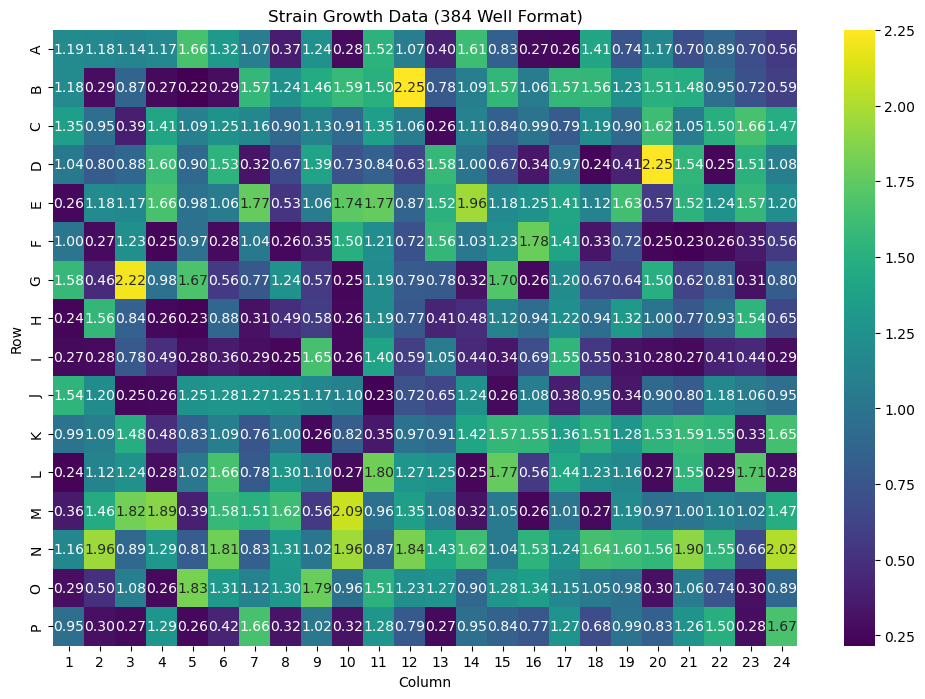

In [73]:
#plot the data for each well in df_combined in 384 well format (like a heatmap) with col on the x axis and row letter on the y
plt.figure(figsize=(12, 8))
#show the values as white text on the heatmap
sns.heatmap(df_pivot,  cmap='viridis', annot=True, fmt=".2f")
plt.xlabel('Column')
plt.ylabel('Row')
plt.title('Strain Growth Data (384 Well Format)')
plt.show()

In [78]:
#filter df_combined to rows with Value > .32
df_combined_filtered = df_combined[df_combined['Value'].astype(float) > .32]
df_combined_filtered['Well_Position'] = df_combined_filtered.apply(lambda row: f"{row['Row_Letter']}{row['Column']}", axis=1)
display(df_combined_filtered)
wells_with_growth = set(df_combined_filtered['Well_Position'].unique())
final_selection = wells_with_growth.intersection(overlap)
print(f"Final selection of wells with growth and in picklist: {len(final_selection)}")
print(final_selection)

/tmp/ipykernel_4177951/1784199705.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_combined_filtered['Well_Position'] = df_combined_filtered.apply(lambda row: f"{row['Row_Letter']}{row['Column']}", axis=1)


,Cycle,Time,T,Row_Letter,Row_No,Column,Value,Well_Position
0,2,180,30.4,A,0,1,1.185,A1
1,2,180,30.4,A,0,3,1.143,A3
2,2,180,30.4,A,0,5,1.659,A5
3,2,180,30.4,A,0,7,1.071,A7
4,2,180,30.4,A,0,9,1.241,A9
...,...,...,...,...,...,...,...,...
379,1,0,30.7,P,15,16,0.767,P16
380,1,0,30.7,P,15,18,0.680,P18
381,1,0,30.7,P,15,20,0.829,P20
382,1,0,30.7,P,15,22,1.498,P22


Final selection of wells with growth and in picklist: 90
{'F17', 'O9', 'F5', 'G3', 'E24', 'C14', 'M19', 'E2', 'H11', 'E10', 'D23', 'E13', 'O11', 'G6', 'E4', 'A2', 'O13', 'I3', 'A12', 'G18', 'G4', 'O3', 'G9', 'A21', 'C22', 'E20', 'O21', 'A6', 'P15', 'A14', 'F15', 'G13', 'G12', 'P17', 'E15', 'M9', 'J5', 'E9', 'G1', 'J13', 'M17', 'E14', 'E7', 'E5', 'I9', 'J9', 'M11', 'H17', 'E6', 'P21', 'A1', 'G2', 'E12', 'O7', 'E16', 'A11', 'F23', 'P11', 'A15', 'E21', 'C24', 'O19', 'E22', 'G5', 'J1', 'A8', 'H23', 'G20', 'G8', 'C20', 'I11', 'G19', 'E8', 'G15', 'O17', 'G7', 'H15', 'G17', 'H19', 'E18', 'F19', 'M21', 'F7', 'G21', 'O15', 'M13', 'P19', 'G22', 'G11', 'F13'}


In [77]:
#print the names of the strains from overlap that were not in the final selection
excluded_wells = overlap - final_selection
excluded_strains = df_merged[df_merged['Well.position'].isin(excluded_wells)]['strain'].unique()
print(f"Excluded strains (in overlap but not in final selection): {excluded_strains}")
print(excluded_wells)

Excluded strains (in overlap but not in final selection): ['18' '171' '204' '208' '203' '181' '183' '227' '235' '144']
{'P23', 'H5', 'F21', 'G23', 'A10', 'J3', 'H7', 'J11', 'G10', 'G14'}
